# Example 01 - Basic four-asset portfolio

The smallest complete tour of the pipeline, fully offline and deterministic:

1. generate a seeded synthetic price history for four assets;
2. turn it into a QUBO with the Rust core (`qaoa_portfolio_core.build_qubo`);
3. find the exact optimum by brute force (the ground truth);
4. solve the same QUBO with QAOA (PennyLane statevector simulator);
5. compare the two and plot composition, convergence, and probabilities.

This notebook mirrors `01_basic_four_assets.py`, which is the tested source of truth.

In [1]:
from pathlib import Path

import qaoa_portfolio_core as core
from qaoa_portfolio import (
    QAOAConfig,
    generate_synthetic_prices,
    plot_portfolio_composition,
    plot_qaoa_convergence,
    plot_solution_probabilities,
    render_qaoa_circuit_summary,
    solve_qubo_qaoa,
)

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

SEED = 7
RISK_FACTOR = 0.5
TARGET_ASSETS = 2
LABELS = ["ALPHA", "BETA", "GAMMA", "DELTA"]

In [2]:
from IPython.display import Image, display

def save_and_show(figures, prefix):
    """Save each figure to output/ (like the script) and display the PNG."""
    paths = []
    for name, figure in figures.items():
        path = OUTPUT_DIR / f"{prefix}_{name}.png"
        figure.savefig(path, bbox_inches="tight", dpi=100)
        paths.append(path)
        display(Image(filename=str(path)))
    return paths

## 1. Data

One year (252 trading days) of seeded synthetic prices, shape `(periods, assets)`.
Each asset gets a slightly higher drift and volatility than the previous one, plus a
shared market factor so the covariance matrix is non-trivial.

In [3]:
prices = generate_synthetic_prices(len(LABELS), periods=252, seed=SEED)
print(f"Price history: {prices.shape[0]} days x {prices.shape[1]} assets")

Price history: 252 days x 4 assets


## 2. QUBO

The Rust core estimates mean returns and covariance from the prices and encodes
*minimize risk - return, select exactly `TARGET_ASSETS`* as a QUBO: binary
`x_i = 1` means asset `i` is held (equal-weighted).

In [4]:
qubo = core.build_qubo(prices, LABELS, RISK_FACTOR, TARGET_ASSETS)
print(f"QUBO: {qubo.num_variables} binary variables, offset {qubo.offset:.4f}")

QUBO: 4 binary variables, offset 1.9717


## 3. Ground truth by brute force

2^4 = 16 candidate portfolios: trivial to enumerate exactly.

In [5]:
exact = core.solve_brute_force(qubo)
optimum_bitstring = "".join("1" if bit else "0" for bit in exact.solution)
print(
    f"Brute force optimum: {list(exact.selected_assets)} "
    f"(bitstring {optimum_bitstring}, objective {exact.objective_value:.6f})"
)

Brute force optimum: ['ALPHA', 'GAMMA'] (bitstring 1010, objective 0.098686)


## 4. QAOA

One QAOA layer (p = 1) optimized with COBYLA, two restarts, on the exact statevector
simulator. `target_assets` makes the result report how much probability lands on
feasible (exactly-k) portfolios; passing the known optimum as a reference bitstring
reports its final probability.

In [6]:
config = QAOAConfig(
    layers=1,
    optimizer="cobyla",
    max_iterations=60,
    num_restarts=2,
    seed=SEED,
    backend="default.qubit",
    target_assets=TARGET_ASSETS,
)
result = solve_qubo_qaoa(
    qubo, labels=LABELS, config=config, reference_bitstrings=[optimum_bitstring]
)
p_opt = result.metadata["reference_probabilities"][optimum_bitstring]
print(render_qaoa_circuit_summary(result))

QAOA Circuit Summary
Qubits (assets): 4
QAOA layers (p): 1
Optimizer: cobyla
Device backend: default.qubit
Structure: |+>^n -> [Cost(gamma_k) -> Mixer(beta_k)] x p -> measure
Optimal gammas: [1.036971211764053]
Optimal betas: [1.3123298332955313]
Best bitstring: 1010
Selected assets: ALPHA, GAMMA
Objective value: 0.098686


## 5. Compare

How QAOA decodes: it keeps the `max_stored_solutions` (default 64) most probable
bitstrings and returns the one with the lowest QUBO objective. With 4 assets all 16
bitstrings fit, so the decoded answer always equals the brute-force optimum here -
by construction, not by merit. The circuit's real quality is how much probability
it puts on the optimum (P(optimum), and its rank in the distribution) and on feasible
portfolios with exactly `TARGET_ASSETS` holdings.

In [7]:
matches = result.best_bitstring == optimum_bitstring
ranked = sorted(result.probabilities, key=result.probabilities.get, reverse=True)
optimum_rank = ranked.index(optimum_bitstring) + 1
uniform = 1 / 2 ** len(LABELS)

print(f"QAOA selection:    {result.selected_assets}")
print(f"Matches optimum:   {matches}")
print(f"P(optimum):        {p_opt:.3f}  (uniform guess: {uniform:.3f})")
print(f"Optimum rank:      {optimum_rank} of {len(ranked)} by probability")
print(f"P(feasible, k={TARGET_ASSETS}): {result.metadata['feasible_probability']:.3f}")
print(f"Optimizer steps:   {result.iterations}, wall time {result.elapsed_ms} ms")

QAOA selection:    ['ALPHA', 'GAMMA']
Matches optimum:   True
P(optimum):        0.110  (uniform guess: 0.062)
Optimum rank:      6 of 16 by probability
P(feasible, k=2): 0.724
Optimizer steps:   48, wall time 1088 ms


## 6. Figures

The plotting helpers return Matplotlib figures without calling `show()`; they are
saved to `output/` (as the script does) and displayed from the saved PNG.

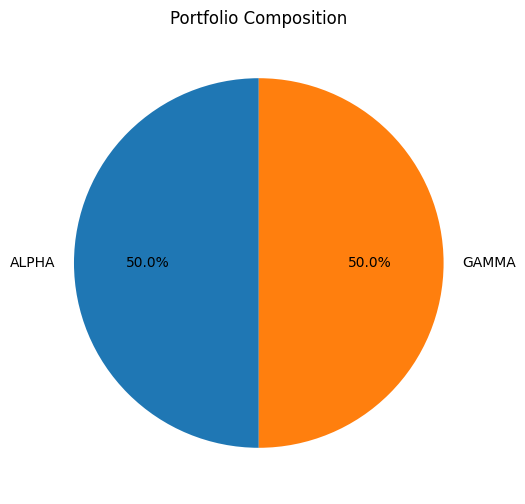

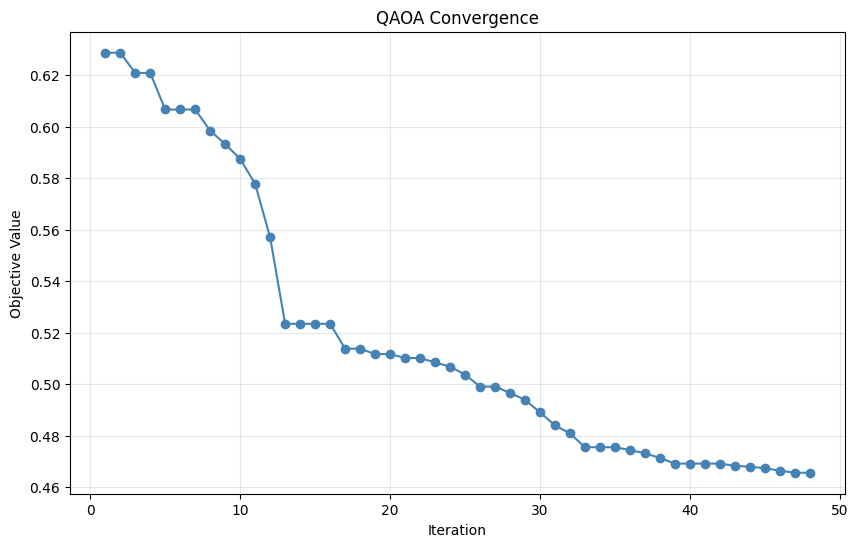

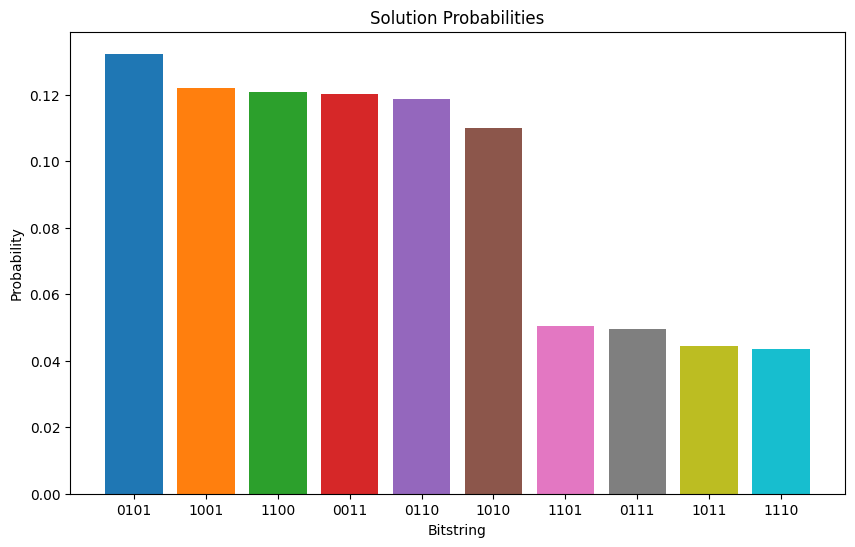

In [8]:
paths = save_and_show(
    {
        "composition": plot_portfolio_composition(result.selected_assets),
        "convergence": plot_qaoa_convergence(result),
        "probabilities": plot_solution_probabilities(result),
    },
    prefix="01",
)